<a href="https://colab.research.google.com/github/RISHITH9/CKD/blob/main/CKD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics -q
print("✅ Done!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00
✅ Done!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Stage4.v4i.yolov8.zip to Stage4.v4i.yolov8.zip
Saving Stage3.v4i.yolov8.zip to Stage3.v4i.yolov8.zip
Saving Stage2.v4i.yolov8.zip to Stage2.v4i.yolov8.zip
Saving Stage0.v4i.yolov8.zip to Stage0.v4i.yolov8.zip
Saving Stage1.v4i.yolov8.zip to Stage1.v4i.yolov8.zip


In [3]:
import zipfile, os, shutil

os.makedirs("/content/merged/images/train", exist_ok=True)
os.makedirs("/content/merged/images/val", exist_ok=True)
os.makedirs("/content/merged/images/test", exist_ok=True)
os.makedirs("/content/merged/labels/train", exist_ok=True)
os.makedirs("/content/merged/labels/val", exist_ok=True)
os.makedirs("/content/merged/labels/test", exist_ok=True)

for zip_name in uploaded.keys():
    stage = zip_name.split(".")[0]
    extract_path = f"/content/{stage}"
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    for split in ["train", "val", "test"]:
        for folder in ["images", "labels"]:
            src = f"{extract_path}/{split}/{folder}"
            dst = f"/content/merged/{folder}/{split}"
            if os.path.exists(src):
                for f in os.listdir(src):
                    shutil.copy(f"{src}/{f}", f"{dst}/{stage}_{f}")

print("✅ All merged!")
print("Train images:", len(os.listdir("/content/merged/images/train")))
print("Val images:", len(os.listdir("/content/merged/images/val")))


✅ All merged!
Train images: 872
Val images: 0


In [4]:
!pip install pytorch-tabnet scikit-learn catboost shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [5]:
import numpy as np

In [6]:
import pandas as pd

In [7]:
# PREPROCESSING STEP 1: Setup and load annotations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import time

# Set paths
BASE_DIR = '/content/merged'
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
LABELS_DIR = os.path.join(BASE_DIR, 'labels')

# Check directories
print("Checking directory structure...")
for split in ['train', 'val', 'test']:
    img_path = os.path.join(IMAGES_DIR, split)
    label_path = os.path.join(LABELS_DIR, split)
    if os.path.exists(img_path):
        num_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f"✓ {split}: {num_imgs} images")
    else:
        print(f"⚠ {split}: NOT FOUND")

Checking directory structure...
✓ train: 872 images
✓ val: 0 images
✓ test: 0 images


In [8]:
# PREPROCESSING STEP 2: Parse YOLO annotations and extract image stats

def parse_yolo_annotation(txt_file):
    """
    Parse YOLO format .txt file
    Returns list of bounding boxes
    Format: <class_id> <x_center> <y_center> <width> <height> (all 0-1 normalized)
    """
    annotations = []

    if not os.path.exists(txt_file):
        return annotations

    try:
        with open(txt_file, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                annotations.append({
                    'class_id': int(parts[0]),
                    'x_center': float(parts[1]),
                    'y_center': float(parts[2]),
                    'width': float(parts[3]),
                    'height': float(parts[4])
                })
    except:
        pass

    return annotations

def get_image_stats(image_path):
    """
    Extract image properties
    """
    try:
        img = Image.open(image_path)
        img_array = np.array(img)

        # Handle grayscale vs color
        if len(img_array.shape) == 2:
            channels = 1
            brightness_array = img_array
        else:
            channels = img_array.shape[2]
            brightness_array = np.mean(img_array, axis=2)

        return {
            'width': img.size[0],
            'height': img.size[1],
            'channels': channels,
            'size_kb': os.path.getsize(image_path) / 1024,
            'mean_brightness': np.mean(brightness_array),
            'std_brightness': np.std(brightness_array),
            'aspect_ratio': img.size[0] / img.size[1] if img.size[1] != 0 else 1,
            'is_valid': True
        }
    except Exception as e:
        return {'width': 0, 'height': 0, 'channels': 0, 'size_kb': 0,
                'mean_brightness': 0, 'std_brightness': 0, 'aspect_ratio': 0,
                'is_valid': False}

print("✅ Functions created: parse_yolo_annotation() and get_image_stats()")

# Test on first image
test_img_files = os.listdir(os.path.join(IMAGES_DIR, 'train'))
if test_img_files:
    test_img = test_img_files[0]
    test_img_path = os.path.join(IMAGES_DIR, 'train', test_img)
    test_label_path = os.path.join(LABELS_DIR, 'train', test_img.rsplit('.', 1)[0] + '.txt')

    # Get stats
    img_stats = get_image_stats(test_img_path)
    annotations = parse_yolo_annotation(test_label_path)

    print(f"\n📸 Test Image: {test_img}")
    print(f"   Size: {img_stats['width']}x{img_stats['height']}px")
    print(f"   Brightness: {img_stats['mean_brightness']:.1f} (0-255 scale)")
    print(f"   File size: {img_stats['size_kb']:.1f} KB")
    print(f"   Kidney abnormalities detected: {len(annotations)}")
    if annotations:
        print(f"   First box area: {annotations[0]['width'] * annotations[0]['height']:.4f}")

✅ Functions created: parse_yolo_annotation() and get_image_stats()

📸 Test Image: Stage0_stage0-10-_jpg.rf.c027452fa6109cead175959417063a5f.jpg
   Size: 640x480px
   Brightness: 133.7 (0-255 scale)
   File size: 30.6 KB
   Kidney abnormalities detected: 1
   First box area: 0.2319


In [9]:
# PREPROCESSING STEP 3: Build complete metadata dataframe

print("\n" + "="*70)
print("Building metadata dataframe for ALL images...")
print("="*70)

start_time = time.time()
metadata = []

# Loop through splits
for split in ['train', 'val', 'test']:
    split_img_path = os.path.join(IMAGES_DIR, split)
    split_label_path = os.path.join(LABELS_DIR, split)

    if not os.path.exists(split_img_path):
        continue

    # Get all image files
    img_files = [f for f in os.listdir(split_img_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"\nProcessing {split} split: {len(img_files)} images")

    for idx, img_file in enumerate(img_files):
        # Progress indicator
        if (idx + 1) % 200 == 0:
            elapsed = time.time() - start_time
            print(f"  [{idx+1}/{len(img_files)}] - {elapsed:.1f}s")

        # Image path
        img_path = os.path.join(split_img_path, img_file)

        # Label path
        label_name = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(split_label_path, label_name)

        # Get image stats
        img_stats = get_image_stats(img_path)

        if not img_stats['is_valid']:
            continue  # Skip broken images

        # Get annotations
        annotations = parse_yolo_annotation(label_path)
        num_boxes = len(annotations)

        # Calculate box statistics
        if num_boxes > 0:
            box_areas = [a['width'] * a['height'] for a in annotations]
            avg_box_area = np.mean(box_areas)
            max_box_area = np.max(box_areas)
            min_box_area = np.min(box_areas)
        else:
            avg_box_area = max_box_area = min_box_area = 0

        # Store metadata
        metadata.append({
            'filename': img_file,
            'split': split,
            'width': img_stats['width'],
            'height': img_stats['height'],
            'channels': img_stats['channels'],
            'size_kb': img_stats['size_kb'],
            'mean_brightness': img_stats['mean_brightness'],
            'std_brightness': img_stats['std_brightness'],
            'aspect_ratio': img_stats['aspect_ratio'],
            'num_boxes': num_boxes,
            'avg_box_area': avg_box_area,
            'max_box_area': max_box_area,
            'min_box_area': min_box_area
        })

# Create DataFrame
df_metadata = pd.DataFrame(metadata)

elapsed = time.time() - start_time
print(f"\n" + "-"*70)
print(f"✅ Metadata built in {elapsed:.1f}s")
print(f"✅ Total images processed: {len(df_metadata)}")
print(f"✅ DataFrame shape: {df_metadata.shape}")
print(f"-"*70)
print(f"\nFirst 10 rows:")
print(df_metadata.head(10))


Building metadata dataframe for ALL images...

Processing train split: 872 images
  [200/872] - 15.9s
  [400/872] - 30.3s
  [600/872] - 39.3s
  [800/872] - 49.1s

Processing val split: 0 images

Processing test split: 0 images

----------------------------------------------------------------------
✅ Metadata built in 52.5s
✅ Total images processed: 872
✅ DataFrame shape: (872, 13)
----------------------------------------------------------------------

First 10 rows:
                                            filename  split  width  height  \
0  Stage0_stage0-10-_jpg.rf.c027452fa6109cead1759...  train    640     480   
1  Stage1_stage1-9-_png.rf.f1910c2b011f414d207ff4...  train    640     480   
2  Stage3_stage3-43-_jpg.rf.ef6c26bbc715137e2a3ed...  train    640     480   
3  Stage2_stage2-41-_jpg.rf.7bb6d1b6cc02884c1d9fa...  train    640     480   
4  Stage4_iris-stage-4-56-_png.rf.1ab3873c2c6fe4d...  train   1708     958   
5  Stage1_iris-stage-1-17-_png.rf.1531801b88affcf...  train 

In [10]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
IMAGES_DIR = '/content/merged/images/train'
LABELS_DIR = '/content/merged/labels/train'

print("✓ Libraries imported")
print(f"✓ Images folder: {IMAGES_DIR}")
print(f"✓ Labels folder: {LABELS_DIR}")


✓ Libraries imported
✓ Images folder: /content/merged/images/train
✓ Labels folder: /content/merged/labels/train


In [11]:
# Get all image files
image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"Total images: {len(image_files)}")
print(f"\nFirst 10 images:")
for i, f in enumerate(image_files[:10]):
    print(f"  {i+1}. {f}")


Total images: 872

First 10 images:
  1. Stage0_stage0-10-_jpg.rf.c027452fa6109cead175959417063a5f.jpg
  2. Stage1_stage1-9-_png.rf.f1910c2b011f414d207ff49589840510.jpg
  3. Stage3_stage3-43-_jpg.rf.ef6c26bbc715137e2a3edd58f7bbf7d0.jpg
  4. Stage2_stage2-41-_jpg.rf.7bb6d1b6cc02884c1d9fabcc0b2bc88c.jpg
  5. Stage4_iris-stage-4-56-_png.rf.1ab3873c2c6fe4d753b60f9b04066b8b.jpg
  6. Stage1_iris-stage-1-17-_png.rf.1531801b88affcfe8d3f623b17bd9336.jpg
  7. Stage4_stage4-11-_jpg.rf.5fb0988cb6716ff80e4f0897d8702d24.jpg
  8. Stage4_iris-stage-4-59-_png.rf.725124956286a48e2baf3e31d8107461.jpg
  9. Stage1_iris-stage-1-21-_png.rf.7866c824b4bb554cc5c0931ec9268875.jpg
  10. Stage4_iris-stage-4-71-_png.rf.9c40c94472c03ff6d236d266de90f3f5.jpg


In [12]:
# Store image info
image_info = []

for img_file in image_files[:100]:  # First 100 images (not all yet)
    img_path = os.path.join(IMAGES_DIR, img_file)

    # Open image
    img = Image.open(img_path)
    img_array = np.array(img)

    # Get properties
    width, height = img.size
    channels = img_array.shape[2] if len(img_array.shape) == 3 else 1

    # Calculate brightness (average pixel value)
    brightness = np.mean(img_array)

    # Calculate contrast (variation in pixels)
    contrast = np.std(img_array)

    # File size
    file_size_kb = os.path.getsize(img_path) / 1024

    # Store
    image_info.append({
        'filename': img_file,
        'width': width,
        'height': height,
        'channels': channels,
        'brightness': brightness,
        'contrast': contrast,
        'file_size_kb': file_size_kb
    })

print(f"✓ Processed {len(image_info)} images")
print(f"\nSample data (first 5 images):")
for info in image_info[:5]:
    print(info)


✓ Processed 100 images

Sample data (first 5 images):
{'filename': 'Stage0_stage0-10-_jpg.rf.c027452fa6109cead175959417063a5f.jpg', 'width': 640, 'height': 480, 'channels': 3, 'brightness': np.float64(133.7317426215278), 'contrast': np.float64(105.62440886690145), 'file_size_kb': 30.57421875}
{'filename': 'Stage1_stage1-9-_png.rf.f1910c2b011f414d207ff49589840510.jpg', 'width': 640, 'height': 480, 'channels': 3, 'brightness': np.float64(124.89987521701389), 'contrast': np.float64(111.69726902063653), 'file_size_kb': 26.150390625}
{'filename': 'Stage3_stage3-43-_jpg.rf.ef6c26bbc715137e2a3edd58f7bbf7d0.jpg', 'width': 640, 'height': 480, 'channels': 3, 'brightness': np.float64(125.96314887152778), 'contrast': np.float64(110.68192426894409), 'file_size_kb': 27.203125}
{'filename': 'Stage2_stage2-41-_jpg.rf.7bb6d1b6cc02884c1d9fabcc0b2bc88c.jpg', 'width': 640, 'height': 480, 'channels': 3, 'brightness': np.float64(130.6121462673611), 'contrast': np.float64(107.21435040498696), 'file_size_kb':

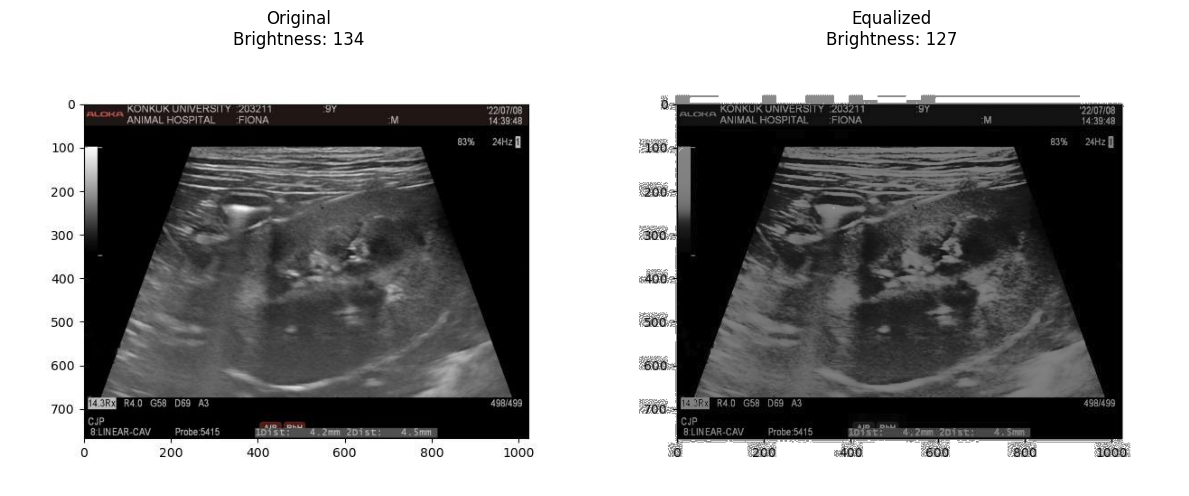

✓ Histogram equalization applied


In [13]:
# CELL: Histogram Equalization

from PIL import Image, ImageEnhance
import cv2

# Method 1: Using OpenCV (BEST for medical images)
def equalize_brightness_cv2(img_path):
    """
    OpenCV histogram equalization
    """
    # Read image
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply histogram equalization
    equalized = cv2.equalizeHist(img_gray)

    return equalized

# Method 2: Using PIL (Simple)
def equalize_brightness_pil(img_path):
    """
    PIL ImageEnhance
    """
    img = Image.open(img_path)
    enhancer = ImageEnhance.Brightness(img)

    # Adjust brightness (1.0 = original, 1.5 = 50% brighter)
    enhanced = enhancer.enhance(1.2)

    return enhanced


# Test on one image
test_img = os.path.join(IMAGES_DIR, image_files[0])

# Original
original = Image.open(test_img)
original_array = np.array(original)

# Equalized
equalized_cv2 = equalize_brightness_cv2(test_img)

# Show comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_array)
axes[0].set_title(f"Original\nBrightness: {np.mean(original_array):.0f}")
axes[0].axis('off')

axes[1].imshow(equalized_cv2, cmap='gray')
axes[1].set_title(f"Equalized\nBrightness: {np.mean(equalized_cv2):.0f}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Histogram equalization applied")


In [14]:
# CELL: Find Max Image Size

import cv2

max_width = 0
max_height = 0

print("Finding max image size in dataset...")

for img_file in image_files[:100]:  # Check first 100
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path)

    if img is None:
        continue

    height, width = img.shape[:2]

    if width > max_width:
        max_width = width
    if height > max_height:
        max_height = height

print(f"\n✓ Max size found:")
print(f"  Width: {max_width}px")
print(f"  Height: {max_height}px")
print(f"  Target size: {max_width}x{max_height}")

# Store for later use
TARGET_WIDTH = max_width
TARGET_HEIGHT = max_height


Finding max image size in dataset...

✓ Max size found:
  Width: 1708px
  Height: 958px
  Target size: 1708x958


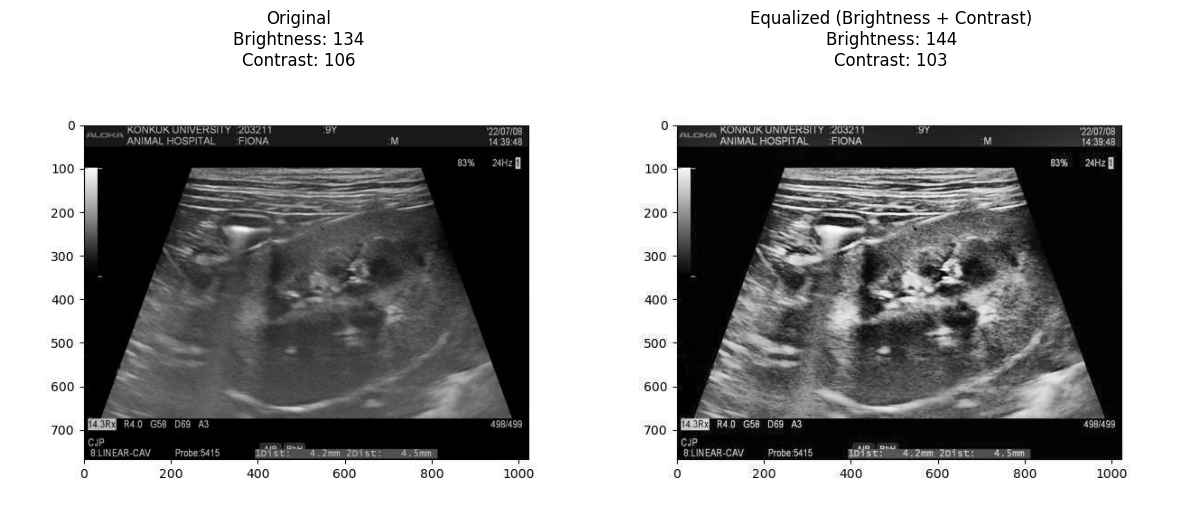

✓ Brightness + Contrast equalized


In [15]:
# CELL: Equalize Brightness & Contrast (CLAHE)

import cv2

def equalize_brightness_contrast(img_path):
    """
    Equalize both brightness and contrast using CLAHE

    CLAHE = Contrast Limited Adaptive Histogram Equalization
    Best for medical ultrasound images
    """
    # Read image as grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # Apply CLAHE for brightness AND contrast
    # clipLimit: controls contrast strength (higher = stronger)
    # tileGridSize: size of tiles (8x8 is standard for medical)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    equalized = clahe.apply(img)

    return equalized

# Test on one image
test_img_path = os.path.join(IMAGES_DIR, image_files[0])
original = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
equalized = equalize_brightness_contrast(test_img_path)

# Show comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title(f"Original\nBrightness: {np.mean(original):.0f}\nContrast: {np.std(original):.0f}")
axes[0].axis('off')

axes[1].imshow(equalized, cmap='gray')
axes[1].set_title(f"Equalized (Brightness + Contrast)\nBrightness: {np.mean(equalized):.0f}\nContrast: {np.std(equalized):.0f}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Brightness + Contrast equalized")


Original shape: (480, 640)
Resized shape: (958, 1708)


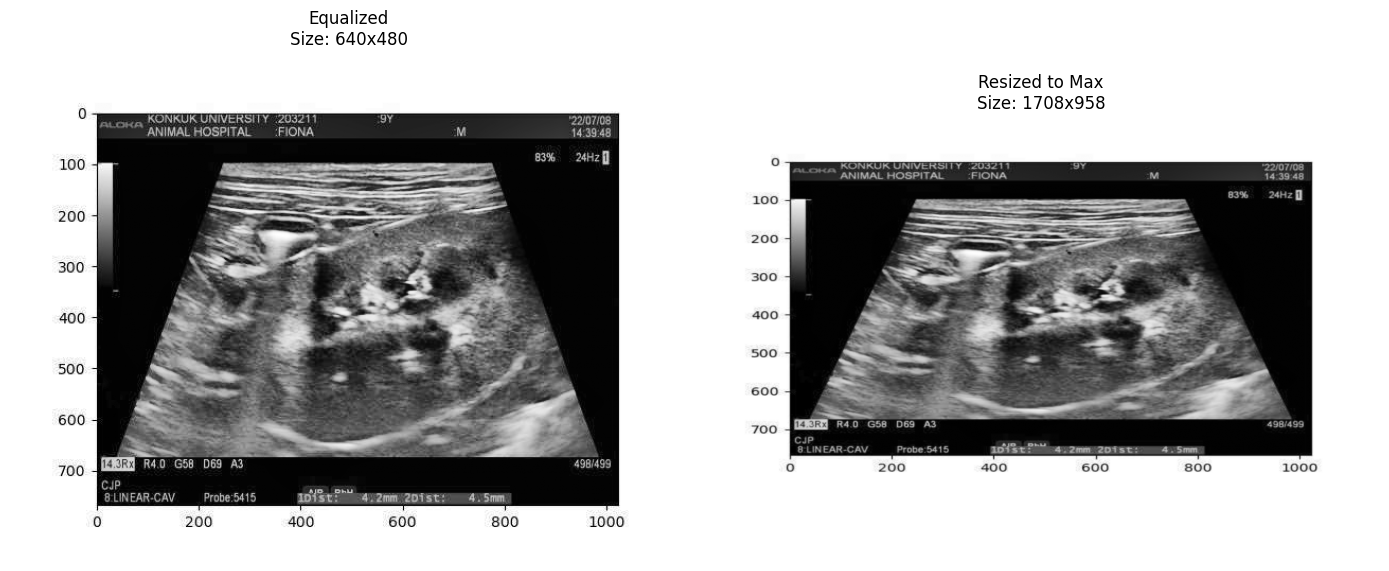

✓ Resizing works correctly


In [16]:
# CELL: Resize to Max Size

import cv2

def resize_to_max_size(img, target_width, target_height):
    """
    Resize image to target size
    """
    # cv2.INTER_LINEAR = good quality for medical images
    resized = cv2.resize(img, (target_width, target_height),
                        interpolation=cv2.INTER_LINEAR)

    return resized

# Test on one image
test_equalized = equalize_brightness_contrast(test_img_path)
test_resized = resize_to_max_size(test_equalized, TARGET_WIDTH, TARGET_HEIGHT)

print(f"Original shape: {test_equalized.shape}")
print(f"Resized shape: {test_resized.shape}")

# Show comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(test_equalized, cmap='gray')
axes[0].set_title(f"Equalized\nSize: {test_equalized.shape[1]}x{test_equalized.shape[0]}")
axes[0].axis('off')

axes[1].imshow(test_resized, cmap='gray')
axes[1].set_title(f"Resized to Max\nSize: {test_resized.shape[1]}x{test_resized.shape[0]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Resizing works correctly")


In [17]:
# CELL: Complete Preprocessing - All Images

import cv2
import os
from tqdm import tqdm

# Create output folder
processed_dir = '/content/processed_images'
os.makedirs(processed_dir, exist_ok=True)

print("="*70)
print("PROCESSING ALL IMAGES")
print("="*70)
print(f"Input: {IMAGES_DIR}")
print(f"Output: {processed_dir}")
print(f"Target size: {TARGET_WIDTH}x{TARGET_HEIGHT}")
print(f"Operations: Equalize brightness + Equalize contrast + Resize")
print("="*70)

processed_stats = []

# Process ALL images
for img_file in tqdm(image_files, desc="Processing"):
    try:
        # Read original
        img_path = os.path.join(IMAGES_DIR, img_file)
        original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if original_img is None:
            continue

        # Get original size
        orig_height, orig_width = original_img.shape[:2]
        orig_brightness = np.mean(original_img)
        orig_contrast = np.std(original_img)

        # Step 1: Equalize brightness & contrast
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        equalized = clahe.apply(original_img)

        eq_brightness = np.mean(equalized)
        eq_contrast = np.std(equalized)

        # Step 2: Resize to max size
        processed = cv2.resize(equalized, (TARGET_WIDTH, TARGET_HEIGHT),
                              interpolation=cv2.INTER_LINEAR)

        # Step 3: Save
        output_path = os.path.join(processed_dir, img_file)
        cv2.imwrite(output_path, processed)

        # Store statistics
        processed_stats.append({
            'filename': img_file,
            'orig_width': orig_width,
            'orig_height': orig_height,
            'orig_brightness': orig_brightness,
            'orig_contrast': orig_contrast,
            'eq_brightness': eq_brightness,
            'eq_contrast': eq_contrast,
            'final_width': TARGET_WIDTH,
            'final_height': TARGET_HEIGHT
        })

    except Exception as e:
        print(f"Error processing {img_file}: {e}")
        continue

print(f"\n✓ Processed {len(processed_stats)} images")
print(f"✓ Saved to: {processed_dir}")


PROCESSING ALL IMAGES
Input: /content/merged/images/train
Output: /content/processed_images
Target size: 1708x958
Operations: Equalize brightness + Equalize contrast + Resize


Processing: 100%|██████████| 872/872 [00:21<00:00, 40.14it/s]


✓ Processed 872 images
✓ Saved to: /content/processed_images


In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import cv2, os
import numpy as np
from PIL import Image

PROCESSED_DIR = '/content/processed_images'
IMAGE_SIZE = (224, 224)  # ResNet standard input size

# Extract class label from filename prefix (Stage0_, Stage1_, etc.)
def get_label_from_filename(filename):
    stage = filename.split('_')[0]  # e.g., "Stage2"
    return int(stage.replace('Stage', ''))

class KidneyCKDDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.labels = [get_label_from_filename(f) for f in self.files]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.files[idx])
        # Read grayscale processed image → convert to 3-channel for ResNet
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = KidneyCKDDataset(PROCESSED_DIR, transform=transform)

# 80/20 train-val split (since your val folder is empty)
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)

print(f"✅ Train samples: {train_size} | Val samples: {val_size}")
print(f"✅ Classes: Stage0, Stage1, Stage2, Stage3, Stage4")

✅ Train samples: 697 | Val samples: 175
✅ Classes: Stage0, Stage1, Stage2, Stage3, Stage4


In [19]:
NUM_CLASSES = 5  # Stage 0 to 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze all layers, only train the final head
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer for 5-class CKD staging
model.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("✅ ResNet-50 loaded with ImageNet weights")
print(f"✅ Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


✅ ResNet-50 loaded with ImageNet weights
✅ Trainable params: 525,829


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

EPOCHS = 10
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)

    train_acc  = correct / total
    train_loss = total_loss / len(train_loader)

    # --- VALIDATE ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss    += loss.item()
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)
    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"\n✅ Best Val Accuracy: {max(val_accs):.4f}")

Epoch [01/10] | Train Loss: 1.6778 Acc: 0.2195 | Val Loss: 1.5908 Acc: 0.2343
Epoch [02/10] | Train Loss: 1.5855 Acc: 0.2582 | Val Loss: 1.5711 Acc: 0.2229
Epoch [03/10] | Train Loss: 1.5592 Acc: 0.2640 | Val Loss: 1.5579 Acc: 0.2971
Epoch [04/10] | Train Loss: 1.5186 Acc: 0.3286 | Val Loss: 1.4890 Acc: 0.3029
Epoch [05/10] | Train Loss: 1.4815 Acc: 0.3902 | Val Loss: 1.4677 Acc: 0.3600
Epoch [06/10] | Train Loss: 1.4566 Acc: 0.3960 | Val Loss: 1.4563 Acc: 0.3714
Epoch [07/10] | Train Loss: 1.4128 Acc: 0.3859 | Val Loss: 1.4351 Acc: 0.3829
Epoch [08/10] | Train Loss: 1.4045 Acc: 0.4261 | Val Loss: 1.4119 Acc: 0.3829
Epoch [09/10] | Train Loss: 1.3868 Acc: 0.4118 | Val Loss: 1.4015 Acc: 0.3714
Epoch [10/10] | Train Loss: 1.3584 Acc: 0.4476 | Val Loss: 1.3790 Acc: 0.4114

✅ Best Val Accuracy: 0.4114


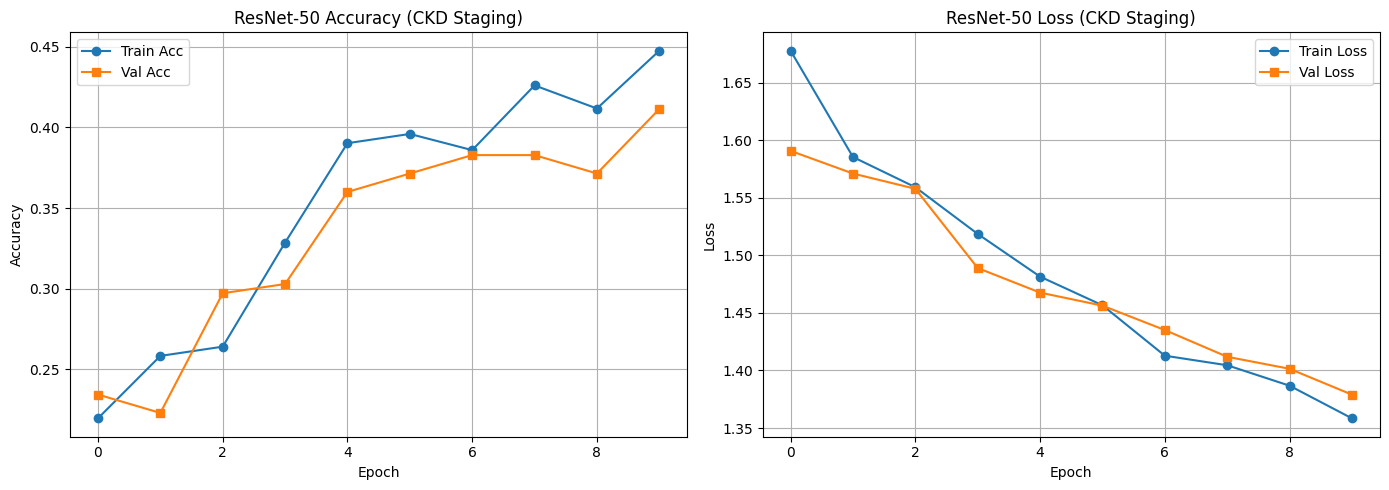

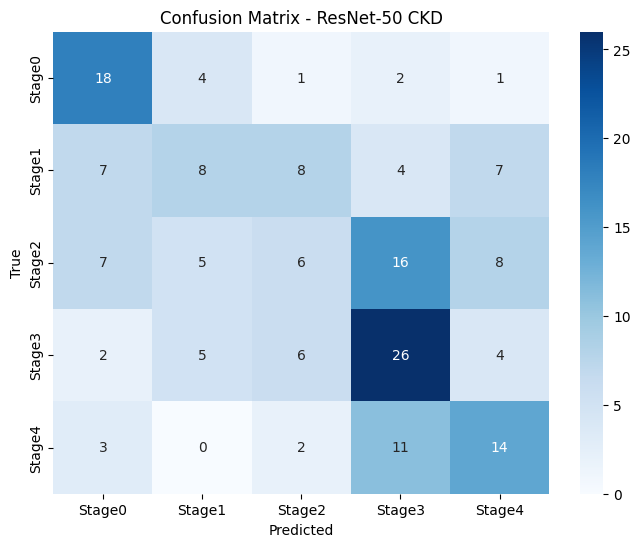


📊 Classification Report:
              precision    recall  f1-score   support

      Stage0       0.49      0.69      0.57        26
      Stage1       0.36      0.24      0.29        34
      Stage2       0.26      0.14      0.18        42
      Stage3       0.44      0.60      0.51        43
      Stage4       0.41      0.47      0.44        30

    accuracy                           0.41       175
   macro avg       0.39      0.43      0.40       175
weighted avg       0.38      0.41      0.38       175



In [21]:
# --- Accuracy & Loss Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_accs, label='Train Acc', marker='o')
axes[0].plot(val_accs,   label='Val Acc',   marker='s')
axes[0].set_title('ResNet-50 Accuracy (CKD Staging)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_losses, label='Train Loss', marker='o')
axes[1].plot(val_losses,   label='Val Loss',   marker='s')
axes[1].set_title('ResNet-50 Loss (CKD Staging)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# --- Confusion Matrix ---
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Stage{i}' for i in range(5)],
            yticklabels=[f'Stage{i}' for i in range(5)])
plt.title('Confusion Matrix - ResNet-50 CKD')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()

print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=[f'Stage{i}' for i in range(5)]))

In [22]:
!pip install pennylane -q
import pennylane as qml
import numpy as np
print(f"✅ PennyLane {qml.__version__} ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 85.5 MB/s eta 0:00:00
✅ PennyLane 0.45.0 ready


In [23]:
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms
from collections import Counter
import cv2, os
from PIL import Image
import torch

PROCESSED_DIR = '/content/processed_images'
NUM_CLASSES = 5

def get_label_from_filename(filename):
    return int(filename.split('_')[0].replace('Stage', ''))

full_files  = [f for f in os.listdir(PROCESSED_DIR) if f.endswith(('.jpg','.jpeg','.png'))]
full_labels = [get_label_from_filename(f) for f in full_files]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class SubsetWithTransform(Dataset):
    def __init__(self, files, labels, indices, image_dir, transform):
        self.files     = [files[i] for i in indices]
        self.labels    = [labels[i] for i in indices]
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = cv2.imread(os.path.join(self.image_dir, self.files[idx]), cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = self.transform(Image.fromarray(img))
        return img, self.labels[idx]

torch.manual_seed(42)
train_size = int(0.8 * len(full_files))
val_size   = len(full_files) - train_size
all_idx    = list(range(len(full_files)))
train_idx  = all_idx[:train_size]
val_idx    = all_idx[train_size:]

train_dataset = SubsetWithTransform(full_files, full_labels, train_idx, PROCESSED_DIR, train_transform)
val_dataset   = SubsetWithTransform(full_files, full_labels, val_idx,   PROCESSED_DIR, val_transform)

# Weighted sampler for class balance
train_labels_list = [full_labels[i] for i in train_idx]
class_counts = Counter(train_labels_list)
weights  = [1.0/class_counts[l] for l in train_labels_list]
sampler  = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,  num_workers=2)

print(f"✅ Train: {train_size} | Val: {val_size}")
print(f"📊 Class distribution: {dict(sorted(class_counts.items()))}")

✅ Train: 697 | Val: 175
📊 Class distribution: {0: 131, 1: 148, 2: 158, 3: 132, 4: 128}


In [24]:
# FASTER: Reduce qubits + batch size + epochs for Colab
N_QUBITS = 4   # was 8 — halves circuit complexity
N_LAYERS = 2   # was 5 — massive speedup

# Redefine circuit with smaller size
dev_fast = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_fast, interface="torch", diff_method="parameter-shift")
def quantum_circuit_fast(inputs, weights):
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(inputs[i] * np.pi, wires=i)
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i+1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class QuantumBatchLayerFast(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 3) * 0.1)
    def forward(self, x):
        results = []
        for i in range(x.shape[0]):
            out = quantum_circuit_fast(x[i, :N_QUBITS], self.weights)
            results.append(torch.stack([o.float() for o in out]))
        return torch.stack(results)

class FastHybridCKD(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_classes=5):
        super().__init__()
        backbone = models.resnet50(weights='IMAGENET1K_V1')
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        for param in self.feature_extractor.parameters():
            param.requires_grad = False  # fully frozen for speed

        self.pre_quantum = nn.Sequential(
            nn.Linear(2048, 64), nn.ReLU(),
            nn.Linear(64, n_qubits), nn.Tanh()
        )
        self.quantum_layer  = QuantumBatchLayerFast()
        self.post_quantum   = nn.Sequential(
            nn.Linear(n_qubits, 32), nn.ReLU(),
            nn.Linear(32, n_classes)
        )
        self.residual_head  = nn.Linear(2048, n_classes)
        self.alpha          = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        feats         = self.feature_extractor(x).view(x.size(0), -1)
        q_out         = self.post_quantum(self.quantum_layer(self.pre_quantum(feats)))
        classical_out = self.residual_head(feats)
        a = torch.sigmoid(self.alpha)
        return a * q_out + (1 - a) * classical_out

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fast_model = FastHybridCKD().to(DEVICE)
print(f"✅ Fast Hybrid Model | {N_QUBITS} qubits | {N_LAYERS} layers")
print(f"✅ Trainable params: {sum(p.numel() for p in fast_model.parameters() if p.requires_grad):,}")

✅ Fast Hybrid Model | 4 qubits | 2 layers
✅ Trainable params: 141,991


In [25]:
from torchvision import models

class ImprovedHybridCKD(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_classes=5):
        super().__init__()
        backbone = models.resnet50(weights='IMAGENET1K_V1')
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        for name, param in self.feature_extractor.named_parameters():
            param.requires_grad = 'layer4' in name

        self.pre_quantum = nn.Sequential(
            nn.Linear(2048, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, n_qubits), nn.Tanh()
        )
        self.quantum_layer  = QuantumBatchLayer()
        self.post_quantum   = nn.Sequential(
            nn.Linear(n_qubits, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(64, n_classes)
        )
        self.residual_head  = nn.Linear(2048, n_classes)
        self.alpha          = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        feats         = self.feature_extractor(x).view(x.size(0), -1)
        q_out         = self.post_quantum(self.quantum_layer(self.pre_quantum(feats)))
        classical_out = self.residual_head(feats)
        a = torch.sigmoid(self.alpha)
        return a * q_out + (1 - a) * classical_out

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hybrid_model = ImprovedHybridCKD().to(DEVICE)
trainable = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f"✅ Hybrid Model ready | Device: {DEVICE} | Trainable params: {trainable:,}")
print(f"✅ Alpha initial: {torch.sigmoid(hybrid_model.alpha).item():.3f}")

NameError: name 'QuantumBatchLayer' is not defined

In [ ]:
all_labels_arr = np.array(full_labels)
class_weights_tensor = torch.tensor(
    [len(all_labels_arr)/(NUM_CLASSES * np.sum(all_labels_arr==c)) for c in range(NUM_CLASSES)],
    dtype=torch.float
).to(DEVICE)

criterion_h = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

quantum_params  = list(hybrid_model.quantum_layer.parameters())
backbone_params = [p for n,p in hybrid_model.feature_extractor.named_parameters() if p.requires_grad]
rest_params     = (list(hybrid_model.pre_quantum.parameters()) +
                   list(hybrid_model.post_quantum.parameters()) +
                   list(hybrid_model.residual_head.parameters()) +
                   [hybrid_model.alpha])

optimizer_h = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 5e-5, 'weight_decay': 1e-4},
    {'params': quantum_params,  'lr': 1e-2, 'weight_decay': 0.0},
    {'params': rest_params,     'lr': 5e-4, 'weight_decay': 1e-4},
])
scheduler_h = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_h, T_max=15, eta_min=1e-6)
print("✅ Optimizer ready | 3 param groups: backbone(5e-5), quantum(1e-2), head(5e-4)")

In [ ]:
EPOCHS = 5
BATCH_SIZE = 8  # smaller = fewer samples per quantum forward pass

fast_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

criterion_f = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_f = torch.optim.Adam(
    filter(lambda p: p.requires_grad, fast_model.parameters()), lr=1e-3
)

best_acc_fast = 0.0
h_train_accs, h_val_accs = [], []

for epoch in range(EPOCHS):
    fast_model.train()
    t_correct, t_total, t_loss = 0, 0, 0
    for batch_idx, (imgs, labels) in enumerate(fast_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_f.zero_grad()
        out  = fast_model(imgs)
        loss = criterion_f(out, labels)
        loss.backward()
        optimizer_f.step()
        t_loss += loss.item()
        _, pred = out.max(1)
        t_correct += pred.eq(labels).sum().item()
        t_total   += labels.size(0)
        # Show live progress per batch
        print(f"  E{epoch+1} Batch {batch_idx+1}/{len(fast_loader)} | Loss:{loss.item():.3f}", end='\r')

    fast_model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            _, pred = fast_model(imgs.to(DEVICE)).max(1)
            v_correct += pred.eq(labels).sum().item()
            v_total   += labels.size(0)

    ta = t_correct/t_total
    va = v_correct/v_total
    h_train_accs.append(ta); h_val_accs.append(va)
    if va > best_acc_fast:
        best_acc_fast = va
        torch.save(fast_model.state_dict(), '/content/hybrid_fast_best.pth')
        tag = "✅ BEST"
    else:
        tag = ""
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] Train:{ta:.4f} | Val:{va:.4f} | α={torch.sigmoid(fast_model.alpha).item():.3f} {tag}")

print(f"\n🏆 Classical: {max(val_accs):.4f} → Quantum Hybrid: {best_acc_fast:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

hybrid_model.load_state_dict(torch.load('/content/hybrid_best.pth'))
hybrid_model.eval()
all_preds_h, all_true_h = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        _, pred = hybrid_model(imgs.to(DEVICE)).max(1)
        all_preds_h.extend(pred.cpu().numpy())
        all_true_h.extend(labels.numpy())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(['Classical\nResNet-50', 'Quantum\nHybrid'],
            [max(val_accs), best_val_acc_q],
            color=['steelblue','tomato'], edgecolor='black', width=0.4)
axes[0].set_ylim(0, 1); axes[0].set_title('Best Val Accuracy: Classical vs Quantum')
for i, v in enumerate([max(val_accs), best_val_acc_q]):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)

axes[1].plot(h_train_accs, 'r-o', label='Train'); axes[1].plot(h_val_accs, 'b-s', label='Val')
axes[1].set_title('Quantum Hybrid Training Curve'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

cm_h = confusion_matrix(all_true_h, all_preds_h)
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=[f'S{i}' for i in range(5)],
            yticklabels=[f'S{i}' for i in range(5)])
axes[2].set_title('Hybrid Confusion Matrix'); axes[2].set_ylabel('True'); axes[2].set_xlabel('Pred')

plt.tight_layout()
plt.savefig('/content/classical_vs_quantum_final.png', dpi=150)
plt.show()

print(classification_report(all_true_h, all_preds_h, target_names=[f'Stage{i}' for i in range(5)]))
print(f"\n📌 Final learned alpha = {torch.sigmoid(hybrid_model.alpha).item():.3f}")
print(f"   (>0.5 = quantum dominated | <0.5 = classical dominated)")